In [1]:
!pip install pandas numpy matplotlib statsmodels scikit-learn plotly dash

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
np.random.seed(42)

hours = pd.date_range(start="2025-01-01", periods=720, freq='H')

# Simulated occupancy
occupancy = np.random.randint(20, 80, size=720)

# Electricity strongly depends on occupancy (less noise)
electricity = 0.8 * occupancy + np.random.normal(0, 2, size=720)

data = pd.DataFrame({
    'timestamp': hours,
    'occupancy': occupancy,
    'electricity_usage': electricity
})

data.set_index('timestamp', inplace=True)

data.head()

,occupancy,electricity_usage
timestamp,,
2025-01-01 00:00:00,58,47.494195
2025-01-01 01:00:00,71,56.395615
2025-01-01 02:00:00,48,37.964638
2025-01-01 03:00:00,34,29.397554
2025-01-01 04:00:00,62,51.250833


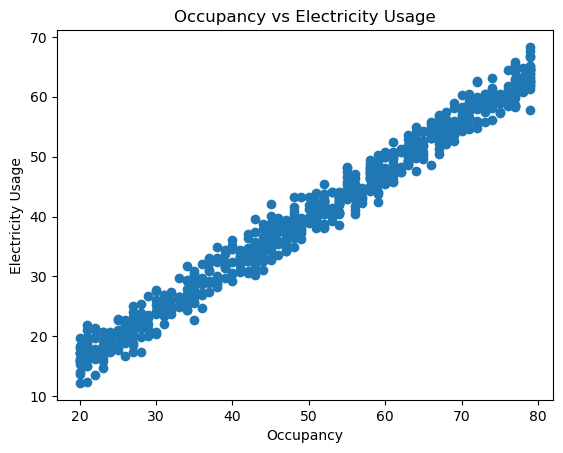

In [4]:
plt.scatter(data['occupancy'], data['electricity_usage'])
plt.xlabel("Occupancy")
plt.ylabel("Electricity Usage")
plt.title("Occupancy vs Electricity Usage")
plt.show()

In [5]:
train = data[:600]
test = data[600:]

train_exog = train['occupancy']
test_exog = test['occupancy']

In [6]:
model = SARIMAX(train['electricity_usage'],
                exog=train_exog,
                order=(1,1,1),
                seasonal_order=(0,0,0,0))

model_fit = model.fit()

print(model_fit.summary())

C:\Users\RITUL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\RITUL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      electricity_usage   No. Observations:                  600
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1255.517
Date:                Thu, 19 Feb 2026   AIC                           2519.034
Time:                        15:18:09   BIC                           2536.615
Sample:                    01-01-2025   HQIC                          2525.879
                         - 01-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
occupancy      0.8018      0.004    179.606      0.000       0.793       0.811
ar.L1          0.0212      0.041      0.513      0.608      -0.060       0.102
ma.L1         -0.9906      0.009   -111.595      0.0

In [7]:
forecast = model_fit.get_forecast(steps=len(test),
                                  exog=test_exog)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

In [8]:
rmse = np.sqrt(mean_squared_error(test['electricity_usage'], forecast_mean))
mae = mean_absolute_error(test['electricity_usage'], forecast_mean)
r2 = r2_score(test['electricity_usage'], forecast_mean)

mape = np.mean(np.abs((test['electricity_usage'] - forecast_mean) /
                       test['electricity_usage'])) * 100

accuracy = 100 - mape

print("Model Performance Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Accuracy (%):", accuracy)

Model Performance Metrics:
RMSE: 1.9323353682851903
MAE: 1.516424269665176
R2 Score: 0.9795404018549099
Accuracy (%): 95.58207025329978


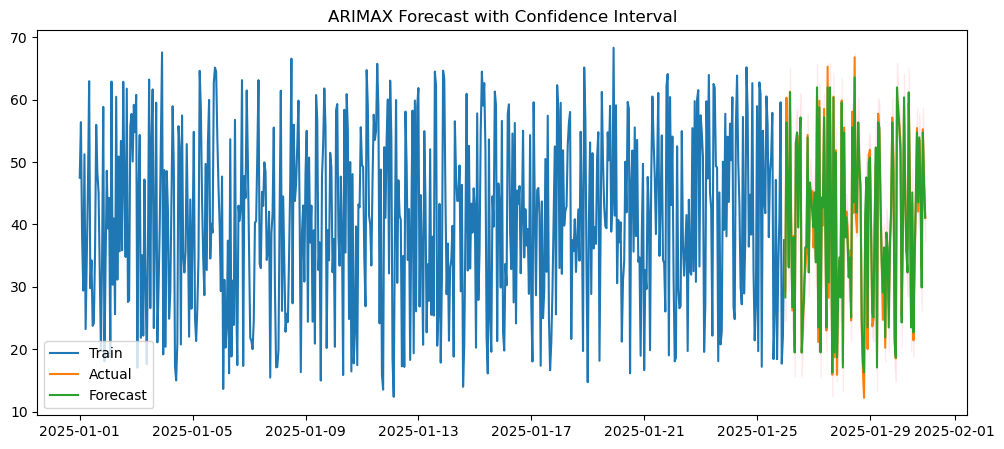

In [9]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['electricity_usage'], label="Train")
plt.plot(test.index, test['electricity_usage'], label="Actual")
plt.plot(test.index, forecast_mean, label="Forecast")

plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("ARIMAX Forecast with Confidence Interval")
plt.show()